# Excepciones y estabilidad

Este cuaderno ayuda a priorizar errores por recurrencia y a distinguir entre incidencias continuas y brotes puntuales.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd()
candidate_roots = [
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == 'notebooks' else NOTEBOOK_CWD,
    NOTEBOOK_CWD / 'observability' / 'd365-fo-observability',
]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'kql_runner.py').exists() and (candidate / 'queries').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('No se pudo localizar observability/d365-fo-observability desde el directorio actual')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from kql_runner import build_client, load_config, load_kql, plot_bar, plot_timeseries, run_kql

config = load_config()
client = build_client(config=config)
EXCEPTIONS_DAYS = config['query_days']

Ejecutando: Exceptions summary
Filas devueltas: 30


,ExceptionType,ProblemId,OuterMessage,Occurrences,FirstSeen,LastSeen,ImpactedUsers,ExceptionLabel
0,System.Exception,System.Exception,Se ha cancelado el registro.,24,2026-07-02 09:53:02.645705+00:00,2026-07-06 15:11:45.996151+00:00,5,System.Exception | System.Exception
1,System.Exception,System.Exception,La actualización se ha cancelado debido a un e...,5,2026-07-02 09:24:33.991095+00:00,2026-07-06 08:22:06.800949+00:00,2,System.Exception | System.Exception
2,System.Exception,System.Exception,Se produjo un problema al comunicarse con el s...,5,2026-07-02 08:58:26.119677+00:00,2026-07-06 08:59:37.661729+00:00,1,System.Exception | System.Exception
3,System.Exception,System.Exception,Seleccione una orden válida.,4,2026-07-02 14:51:49.127406+00:00,2026-07-06 15:21:19.961631+00:00,2,System.Exception | System.Exception
4,System.Exception,System.Exception,Errores de validación al ejecutar 'Asignación ...,3,2026-07-02 12:09:40.235488+00:00,2026-07-02 14:56:49.357046+00:00,2,System.Exception | System.Exception
5,System.Exception,System.Exception,No se pueden generar los pagos,3,2026-07-02 12:09:40.331037+00:00,2026-07-02 14:56:49.400366+00:00,2,System.Exception | System.Exception
6,System.Exception,System.Exception,El diario VB02-000001 está siendo utilizado po...,2,2026-07-03 06:26:42.750101+00:00,2026-07-03 06:26:52.400481+00:00,1,System.Exception | System.Exception
7,System.Exception,System.Exception,Se ha producido una excepción y el procesamien...,2,2026-07-02 14:02:37.395980+00:00,2026-07-03 08:23:43.209530+00:00,1,System.Exception | System.Exception
8,System.Exception,System.Exception,Se ha llamado a la función LedgerJournalContro...,2,2026-07-03 16:32:58.786827+00:00,2026-07-03 16:33:05.297427+00:00,1,System.Exception | System.Exception
9,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,1,2026-07-03 04:51:35.260028+00:00,2026-07-03 04:51:35.260028+00:00,1,System.Exception | System.Exception


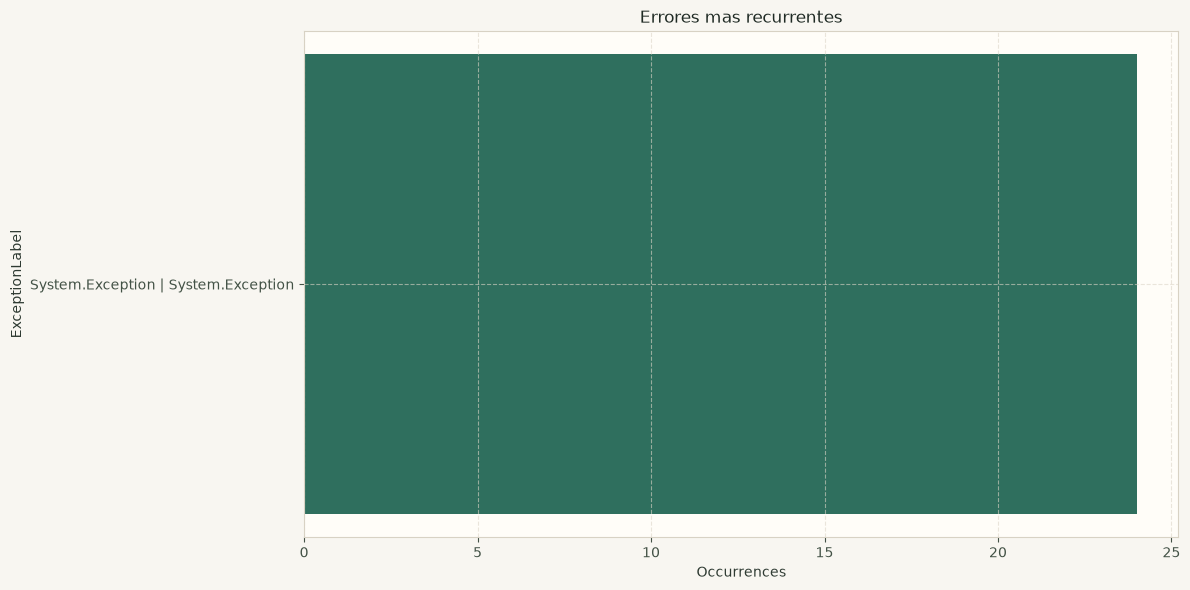

In [2]:
df_summary = run_kql(client, load_kql('40_exceptions.kql'), days=EXCEPTIONS_DAYS, name='Exceptions summary', config=config)
df_summary['ExceptionLabel'] = df_summary['ExceptionType'].astype(str) + ' | ' + df_summary['ProblemId'].astype(str)
display(df_summary.head(20))
plot_bar(df_summary, 'ExceptionLabel', 'Occurrences', 'Errores mas recurrentes', top_n=15)

Ejecutando: Exceptions timeseries
Filas devueltas: 110


,timestamp,Exceptions
86,2026-07-05 23:00:00+00:00,1
87,2026-07-06 00:00:00+00:00,1
88,2026-07-06 01:00:00+00:00,1
89,2026-07-06 02:00:00+00:00,1
90,2026-07-06 03:00:00+00:00,1
91,2026-07-06 04:00:00+00:00,1
92,2026-07-06 05:00:00+00:00,1
93,2026-07-06 06:00:00+00:00,1
94,2026-07-06 07:00:00+00:00,2
95,2026-07-06 08:00:00+00:00,5


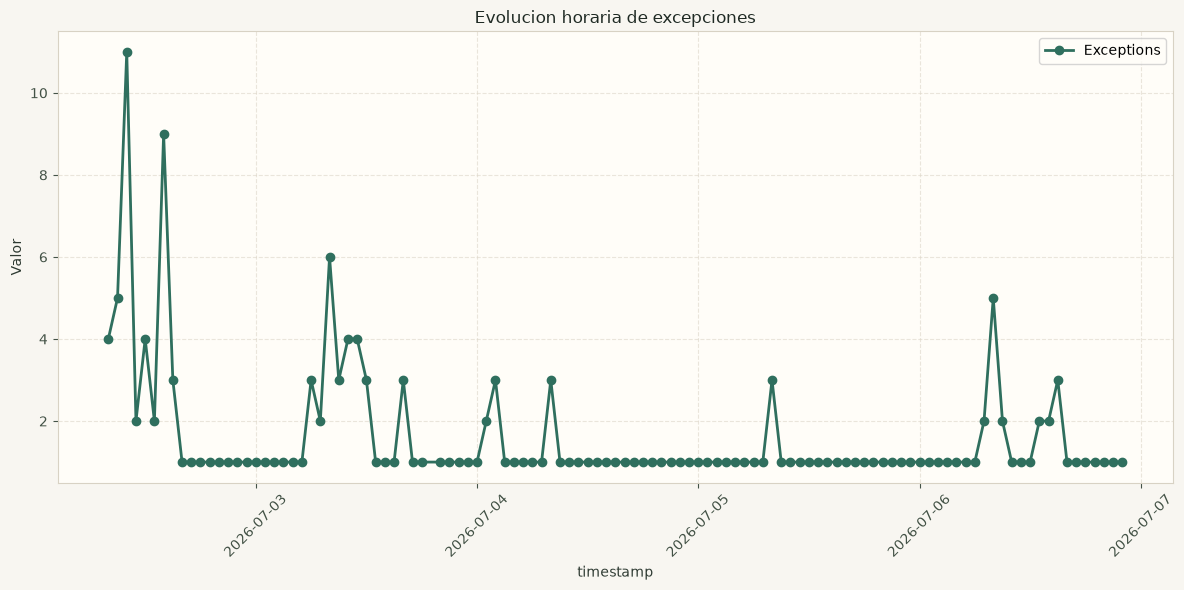

Ejecutando: Latest exceptions
Filas devueltas: 34


,timestamp,user_Id,session_Id,operation_Id,ExceptionType,ProblemId,OuterMessage,Details
0,2026-07-06 22:42:33.437568+00:00,Admin,11694,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
1,2026-07-06 21:42:35.720155+00:00,Admin,11666,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
2,2026-07-06 20:42:32.800504+00:00,Admin,11640,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
3,2026-07-06 19:41:36.811264+00:00,Admin,11666,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
4,2026-07-06 18:41:26.345569+00:00,Admin,11640,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
5,2026-07-06 17:40:32.944519+00:00,Admin,11639,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
6,2026-07-06 16:39:34.315142+00:00,Admin,11666,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
7,2026-07-06 15:38:36.012576+00:00,Admin,11671,,System.Exception,System.Exception,No se puede recuperar el token. Error: invalid...,"[{""outerId"":""0"",""message"":""No se puede recuper..."
8,2026-07-06 15:21:19.961631+00:00,Admin,11639,,System.Exception,System.Exception,Seleccione una orden válida.,"[{""outerId"":""0"",""message"":""Seleccione una orde..."
9,2026-07-06 15:11:45.996151+00:00,olga.garcia,12003,,System.Exception,System.Exception,Se ha cancelado el registro.,"[{""outerId"":""0"",""message"":""Se ha cancelado el ..."


In [3]:
df_timeseries = run_kql(client, load_kql('41_exceptions_timeseries.kql'), days=EXCEPTIONS_DAYS, name='Exceptions timeseries', config=config)
display(df_timeseries.tail(24))
plot_timeseries(df_timeseries, 'timestamp', ['Exceptions'], 'Evolucion horaria de excepciones')

df_latest = run_kql(client, load_kql('42_latest_exceptions.kql'), days=EXCEPTIONS_DAYS, name='Latest exceptions', config=config)
display(df_latest.head(30))

## Recomendacion de visualizacion

- Ranking por Occurrences para portada o backlog de problemas.
- Serie temporal para detectar regresiones tras despliegues o picos de negocio.
- Latest exceptions como vista de detalle, no como primer widget salvo que el equipo trabaje en modo soporte reactivo.